### Model Training: Support Vector Machine(SVM) & Extreme Gradient Boosting(XGBoost)

#### 1. Setup

In [69]:
#Import necessary libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
import joblib

In [49]:
warnings.filterwarnings('ignore')

#### 2. Load The Data

In [50]:
df = pd.read_csv("../data/cleaned_data.csv")

In [51]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### 3. Data Preprocessing

##### 3.1 Binary Encoding

* First converts categorical data into integers, then converts these numbers to the binary (0 and 1) number system and separates them into different columns.

In [52]:
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
               'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 
               'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    if col == 'gender':
        df[col] = df[col].map({'Female': 1, 'Male': 0})
    else:
        df[col] = df[col].map({'Yes': 1, 'No': 0})

In [53]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,0,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,0,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,0,0,0,0,45,0,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,1,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


##### 3.2 Ordinal Encoding

* Represents categories (ordered data) with integers (such as 0, 1, 2) in a meaningful logical order; used when there is a natural greater-than or hierarchical relationship in the data.

In [54]:
df['Contract'] = df['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})

##### 3.3 One-Hot Encoding

* Converts categorical variables (data with no hierarchical relationship) into a numerical format by creating a separate column for each category (with values ​​of 0 or 1); suitable for cases where there is no hierarchy between categories (nominal).

In [55]:
df = pd.get_dummies(data=df, columns=['PaymentMethod', 'InternetService'], drop_first=True, dtype=int)

* When you set `drop_first=True`, it removes one of the categories (for example, it discards the 'Male' column). If the 'Female' column is 0, the model automatically says "This person must be Male". This improves the model's performance and eliminates unnecessary column redundancy.

In [56]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No
0,1,0,1,0,1,0,0,0,1,0,...,0,1,29.85,29.85,0,0,1,0,0,0
1,0,0,0,0,34,1,0,1,0,1,...,1,0,56.95,1889.50,0,0,0,1,0,0
2,0,0,0,0,2,1,0,1,1,0,...,0,1,53.85,108.15,1,0,0,1,0,0
3,0,0,0,0,45,0,0,1,0,1,...,1,0,42.30,1840.75,0,0,0,0,0,0
4,1,0,0,0,2,1,0,0,0,0,...,0,1,70.70,151.65,1,0,1,0,1,0


#### 4. Model Training

In [57]:
# Split dataset into X and y

X = df.drop('Churn', axis=1)  # Features
y = df['Churn']               # Target


print("X shape:", X.shape)
print("y shape:", y.shape)
# data into train and split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42, stratify=y)

X shape: (7043, 22)
y shape: (7043,)


In [58]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()
# Scaling the numerical features in both training and test sets
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])

# Scale the columns in the test set ONLY with transform (it uses the values ​​learned from training)
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [59]:
# Initialize an empty list to store model scores
model_scores = []

# Create a list of models to evaluate
models = [
    ('Random Forest', RandomForestClassifier(random_state=42),
        {'model__n_estimators': [50, 100, 200],
         'model__max_depth': [None, 10, 20]}),  # Add hyperparameters for Random Forest
    ('Support Vector Machine', SVC(random_state=42, class_weight='balanced'),
        {'model__C': [0.1, 1, 10],
         'model__gamma': ['scale', 'auto']}),  # Add hyperparameters for SVM
    ('Logistic Regression', LogisticRegression(random_state=42, class_weight='balanced'),
        {'model__C': [0.1, 1, 10],
         'model__penalty': ['l1', 'l2']}),  # Add hyperparameters for Logistic Regression
    ('K-Nearest Neighbors', KNeighborsClassifier(),
        {'model__n_neighbors': [3, 5, 7],
         'model__weights': ['uniform', 'distance']}),  # Add hyperparameters for KNN
    ('Decision Tree', DecisionTreeClassifier(random_state=42),
        {'model__max_depth': [None, 10, 20],
         'model__min_samples_split': [2, 5, 10]}),  # Add hyperparameters for Decision Tree
    ('XG Boost', XGBClassifier(random_state=42),
        {'model__n_estimators': [50, 100, 200],
         'model__learning_rate': [0.05, 0.1, 0.5]}),  # Add hyperparameters for XG Boost
]

best_model = None
best_accuracy = 0.0

# Iterate over the models and evaluate their performance
for name, model, param_grid in models:
    # Create a pipeline for each model
    pipeline = Pipeline([
        ('scaler', MinMaxScaler()),  # Feature Scaling
        ('model', model)
    ])

# Hyperparameter tuning using GridSearchCV
    if param_grid:
        grid_search = GridSearchCV(pipeline, param_grid, cv=2)
        grid_search.fit(X_train, y_train)
        pipeline = grid_search.best_estimator_

    # Fit the pipeline on the training data
    pipeline.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = pipeline.predict(X_test)

    # Calculate accuracy score
    accuracy = accuracy_score(y_test, y_pred)

    # Append model name and accuracy to the list
    model_scores.append({'Model': name, 'Accuracy': accuracy})

      # Convert the list to a DataFrame
    scores_df = pd.DataFrame(model_scores)
    # Print the performance metrics
    print("Model:", name)
    print("Test Accuracy:", round(accuracy, 3), "%")
    print()

    # Check if the current model has the best accuracy
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = pipeline

# Retrieve the overall best model
print("Best Model:")
print("Test Accuracy:", best_accuracy)
print("Model Pipeline:", best_model, "with accuracy", round(best_accuracy,2), "%")

Model: Random Forest
Test Accuracy: 0.8 %

Model: Support Vector Machine
Test Accuracy: 0.747 %

Model: Logistic Regression
Test Accuracy: 0.74 %

Model: K-Nearest Neighbors
Test Accuracy: 0.765 %

Model: Decision Tree
Test Accuracy: 0.766 %

Model: XG Boost
Test Accuracy: 0.803 %

Best Model:
Test Accuracy: 0.8034066713981547
Model Pipeline: Pipeline(steps=[('scaler', MinMaxScaler()),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interactio

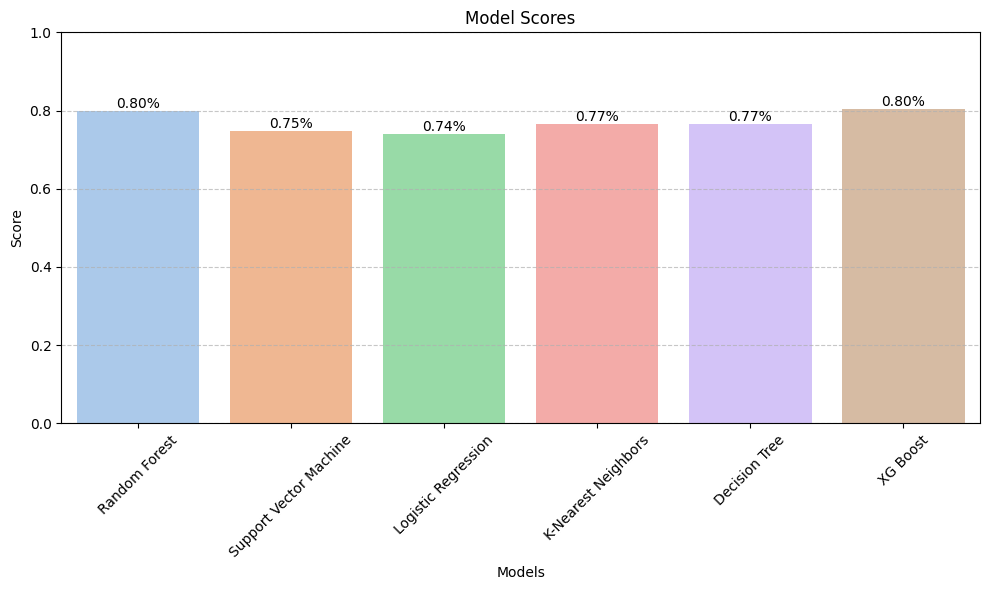

In [60]:
# Create a bar plot of models and their scores
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model', y='Accuracy', data=scores_df, palette="pastel")

# Add text on each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), 
                textcoords='offset points')
    
plt.title('Model Scores')
plt.xlabel('Models')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### 5. Improve SVM Model

In [61]:
# 1. Model Definition
# probability=True: You will need the probability values ​​later if you want to plot the ROC-AUC curve. 
# class_weight='balanced': Automatically gives more weight to the churning minority class.
svm_model = SVC(probability=True, class_weight='balanced', random_state=42)

# 2. Hyperparameter Set
# C: Error margin tolerance (Low C: Wide limit, High C: Tight fit to data)
# gamma: How 'flexible' the decision limit will be
param_grid_svm = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'kernel': ['rbf', 'linear']
}

# 3. GridSearchCV for hyperparameter tuning
grid_svm = GridSearchCV(svm_model, param_grid_svm, cv=5, scoring='f1', n_jobs=-1, verbose=2)

# 4. Training (We use the scaled data we created earlier)
grid_svm.fit(X_train, y_train)

# Print the best parameters
print("Best parameters:", grid_svm.best_params_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}


In [62]:
# 5. Prediction with the best model
y_pred_svm = grid_svm.predict(X_test)

# 6. Reporting the results
print("--- SVM Performans Raporu ---")
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

--- SVM Performans Raporu ---
[[742 293]
 [ 77 297]]
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.50      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



Bu Bölümde Dikkat Etmen Gerekenler:
Neden F1-Score? Telco verisinde "Müşteri kalacak" diyerek %80 başarıyı yakalamak kolaydır. Asıl başarı, gerçekten gidecek olan (1 sınıfı) müşterileri kaçırmamaktır. Recall değeri, gideceklerin yüzde kaçını bildiğini gösterir.


3. Model Karşılaştırma ve Final (En Önemli Kısım)
İki modeli de ayrı ayrı eğittikten sonra, en sonda bir "Model Comparison" bölümü açarak ikisini aynı ringe çıkar:

Her iki modelin Confusion Matrix'ini yan yana koy.

F1-Score ve Recall (Giden müşteriyi yakalama oranı) değerlerini karşılaştır.

Hangi modelin "neden" daha iyi sonuç verdiğine dair bir yorum ekle (Örneğin: "XGBoost kategorik verilerle daha iyi başa çıktı" gibi).

#### 6. Improve XGBoost Model

In [63]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# 1. Calculating weight to handle imbalanced dataset
# Formula: Negative Class Count / Positive Class Count
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_weight = neg_count / pos_count

# 2. Model Definition
xgb_model = XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    scale_pos_weight=scale_weight, 
    use_label_encoder=False,
    eval_metric='logloss'
)

# 3. Hyperparameter Set
param_grid_xgb = {
    'n_estimators': [50,100, 200],          
    'max_depth': [3, 5, 7],              
    'learning_rate': [0.01, 0.05, 0.5, 0.1, 0.2],   
    'subsample': [0.8, 1.0],              
    'colsample_bytree': [0.8, 1.0]       
}

# 4. GridSearchCV 
grid_xgb = GridSearchCV(xgb_model, param_grid_xgb, cv=5, scoring='f1', n_jobs=-1, verbose=1)

# 5. Training 
grid_xgb.fit(X_train, y_train)

print("XGBoost Best Parameters:", grid_xgb.best_params_)

Fitting 5 folds for each of 180 candidates, totalling 900 fits
XGBoost Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


In [74]:
joblib.dump(grid_xgb, '../models/xgboost_first_iteration.pkl')

['../models/xgboost_first_iteration.pkl']

--- XGBoost Performance Report ---
              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1035
           1       0.53      0.80      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



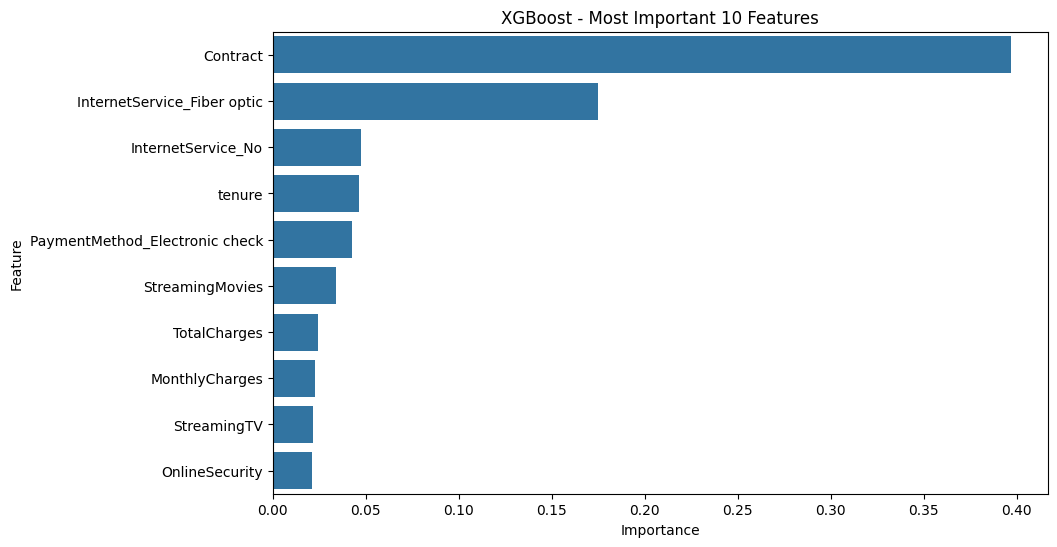

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# ---First Iteration---
# 6. Prediction with the best model
y_pred_xgb = grid_xgb.best_estimator_.predict(X_test)

# 7. Reporting the results
print("--- XGBoost Performance Report ---")
print(classification_report(y_test, y_pred_xgb))

# 8. Feature Importance Visualization
best_xgb = grid_xgb.best_estimator_
features = X.columns
importances = best_xgb.feature_importances_


feature_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10)) 
plt.title('XGBoost - Most Important 10 Features')
plt.show()

In [65]:
# Derive new features from the existing dataframe (df)
df_iter2 = df.copy()


service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df_iter2['TotalServices'] = df_iter2[service_cols].sum(axis=1)

# High monthly charge payers who have been customers for a short time (Risk group)
df_iter2['HighCharge_LowTenure'] = (df_iter2['MonthlyCharges'] > df_iter2['MonthlyCharges'].median()) & (df_iter2['tenure'] < 12)
df_iter2['HighCharge_LowTenure'] = df_iter2['HighCharge_LowTenure'].astype(int)

print("New features added. New column count:", df_iter2.shape[1])
print("df_iter2 head:")
print(df_iter2.head())

New features added. New column count: 25
df_iter2 head:
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       1              0        1           0       1             0   
1       0              0        0           0      34             1   
2       0              0        0           0       2             1   
3       0              0        0           0      45             0   
4       1              0        0           0       2             1   

   MultipleLines  OnlineSecurity  OnlineBackup  DeviceProtection  ...  \
0              0               0             1                 0  ...   
1              0               1             0                 1  ...   
2              0               1             1                 0  ...   
3              0               1             0                 1  ...   
4              0               0             0                 0  ...   

   MonthlyCharges  TotalCharges  Churn  PaymentMethod_Credit card (automatic) 

In [ ]:

X_iter2 = df_iter2.drop('Churn', axis=1)  # Features
y_iter2 = df_iter2['Churn']               # Target

X_train_iter2, X_test_iter2, y_train_iter2, y_test_iter2 = train_test_split(X_iter2, y_iter2, test_size=0.2,random_state=42, stratify=y)


In [73]:
param_grid_refined = {
    'n_estimators': [150, 200, 250],
    'max_depth': [3, 4], 
    'learning_rate': [0.05, 0.1],
    'gamma': [0, 0.1, 0.2],
    'subsample': [0.8, 0.9]
}

grid_xgb_iter2 = GridSearchCV(
    XGBClassifier(objective='binary:logistic', scale_pos_weight=scale_weight, random_state=42),
    param_grid_refined,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_xgb_iter2.fit(X_train_iter2, y_train_iter2)
y_pred_iter2 = grid_xgb_iter2.predict(X_test_iter2)

print("İkinci Iterasyon En İyi Skor:", grid_xgb_iter2.best_score_)
print(classification_report(y_test_iter2, y_pred_iter2))

İkinci Iterasyon En İyi Skor: 0.6344263474826253
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



#### 7. Model Evaluation

##### 1. Support Vector Machine (SVM):

Scores: Recall: 79%, F1: 0.62, Precision: 50%
Comment: Recall improved with unbalanced data parameters, but the F1 score lags behind the Logistic Regression that trained earlier. SVM is a computationally expensive model; training and prediction times become cumbersome when dealing with millions of rows of data. It's not the best candidate for this problem.

##### 2. XGBoost (First Optimization):

Scores: Recall: 80%, F1: 0.64, Precision: 53%
Comment: It managed to keep Recall at 80% while bringing Precision up to 53%. This means it has somewhat better solved the "false positive" problem that occurs in other models. One of the most successful models in terms of Balance (F1 Score).

##### 3. XGBoost (Second Iteration / New Features):

Scores: Recall: 79%, F1: 0.62, Precision: 51%
Comment: New features (TotalServices, etc.) were added, there was a slight decrease in scores. Why? Because the dataset was narrowed by only taking the top 5 features (top_features) and those generated. Decision trees (and XGBoost) are already very adept at finding complex interactions on their own; when other columns were hidden that seem "less important" but are working in the background, the model's knowledge pool shrinks. Feature selection can sometimes backfire.

 📌If we want speed and stability, logistic regression remains strong, but when we consider reducing accuracy and false alarms while also keeping the company budget in mind, XGBoost seems more logical. In this case, we choose the XGBoost model.